EDA + Preprocessing Notebook  
**Dveloped by:** Maitan Yerassyl
**Dataset:** Diabetes Risk Prediction Dataset (Kaggle — vishardmehta)  
**Task type:** Multi-class Classification — predicting `diabetes_risk_category`  
**Hypothesis:** *"We predict that glucose level, BMI, and age are the strongest predictors of diabetes risk category, with glucose being the dominant feature."*

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

RISK_ORDER  = ['Low Risk', 'Prediabetes', 'High Risk']
RISK_COLORS = ['#2ecc71', '#f39c12', '#e74c3c']

---
## 1. Dataset Overview

In [23]:
df = pd.read_csv('diabetes_risk_dataset.csv')
print('Shape:', df.shape)

Shape: (6000, 19)


In [24]:
df.dtypes

Patient_ID                      int64
age                             int64
gender                         object
bmi                           float64
blood_pressure                  int64
fasting_glucose_level           int64
insulin_level                 float64
HbA1c_level                   float64
cholesterol_level               int64
triglycerides_level             int64
physical_activity_level        object
daily_calorie_intake            int64
sugar_intake_grams_per_day    float64
sleep_hours                   float64
stress_level                    int64
family_history_diabetes        object
waist_circumference_cm        float64
diabetes_risk_score           float64
diabetes_risk_category         object
dtype: object

In [25]:
df.isnull().sum()

Patient_ID                    0
age                           0
gender                        0
bmi                           0
blood_pressure                0
fasting_glucose_level         0
insulin_level                 0
HbA1c_level                   0
cholesterol_level             0
triglycerides_level           0
physical_activity_level       0
daily_calorie_intake          0
sugar_intake_grams_per_day    0
sleep_hours                   0
stress_level                  0
family_history_diabetes       0
waist_circumference_cm        0
diabetes_risk_score           0
diabetes_risk_category        0
dtype: int64

In [26]:
df.describe()

,Patient_ID,age,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,waist_circumference_cm,diabetes_risk_score
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,52.230667,32.939667,144.482500,106.105500,15.080333,5.784583,217.490667,177.351500,2479.547000,66.555733,6.998700,5.086500,105.049600,48.691417
std,1732.195139,18.757508,7.510155,17.867248,31.213994,9.245581,0.956614,24.888595,51.897606,548.410642,39.576891,1.331378,2.342989,25.079335,37.242034
min,1.000000,20.000000,16.000000,91.000000,60.000000,2.000000,4.100000,139.000000,50.000000,1200.000000,0.000000,4.000000,1.000000,60.000000,0.000000
25%,1500.750000,36.000000,26.900000,132.000000,87.000000,7.100000,5.200000,200.000000,137.000000,2055.000000,35.100000,6.100000,3.000000,84.700000,12.900000
50%,3000.500000,53.000000,32.750000,144.000000,96.000000,13.800000,5.500000,217.000000,173.000000,2385.000000,58.300000,7.100000,5.000000,104.600000,43.900000
75%,4500.250000,68.000000,38.500000,157.000000,114.000000,21.000000,6.100000,234.000000,213.000000,2848.250000,89.300000,8.000000,7.000000,124.200000,88.800000
max,6000.000000,84.000000,50.000000,200.000000,281.000000,55.900000,11.000000,309.000000,383.000000,5249.000000,255.000000,10.000000,10.000000,150.000000,100.000000


In [27]:
print('Target variable class distribution:')
print(df['diabetes_risk_category'].value_counts())
print()
print('Proportions:')
print(df['diabetes_risk_category'].value_counts(normalize=True).round(3))

Target variable class distribution:
Low Risk       2602
High Risk      2245
Prediabetes    1153
Name: diabetes_risk_category, dtype: int64

Proportions:
Low Risk       0.434
High Risk      0.374
Prediabetes    0.192
Name: diabetes_risk_category, dtype: float64


**Dataset Summary:**  
The dataset contains **6,000 patient records** and **19 columns** covering demographic information (age, gender, BMI), clinical measurements (fasting glucose, HbA1c, blood pressure, insulin, cholesterol, triglycerides), and lifestyle factors (physical activity, calorie intake, sleep, stress, family history). The target variable `diabetes_risk_category` has three classes: *Low Risk* (43.4%), *High Risk* (37.4%), and *Prediabetes* (19.2%). There are **no missing values** in any column. This is a multi-class classification problem: predicting which risk category a patient belongs to based on their clinical and demographic profile. We drop `Patient_ID` (an arbitrary row identifier with no predictive value) and `diabetes_risk_score` (a continuous numeric proxy directly derived from the target label — retaining it would be severe data leakage) before proceeding.

In [28]:
df = df.drop(columns=['Patient_ID', 'diabetes_risk_score'])
print('Columns after dropping leakage/ID columns:', list(df.columns))
print('New shape:', df.shape)

Columns after dropping leakage/ID columns: ['age', 'gender', 'bmi', 'blood_pressure', 'fasting_glucose_level', 'insulin_level', 'HbA1c_level', 'cholesterol_level', 'triglycerides_level', 'physical_activity_level', 'daily_calorie_intake', 'sugar_intake_grams_per_day', 'sleep_hours', 'stress_level', 'family_history_diabetes', 'waist_circumference_cm', 'diabetes_risk_category']
New shape: (6000, 17)


---
## 2. Visualisations

### Plot 1 — Countplot: Target Variable Class Distribution

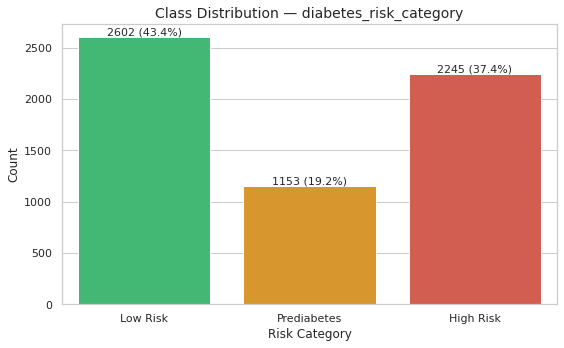

In [29]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='diabetes_risk_category', order=RISK_ORDER, palette=RISK_COLORS)
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=11
    )
plt.title('Class Distribution — diabetes_risk_category', fontsize=14)
plt.xlabel('Risk Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Interpretation:** The dataset is moderately imbalanced — *Low Risk* is the majority class (43.4%), *Prediabetes* is the smallest class (19.2%), and *High Risk* sits in between (37.4%). A naive classifier that predicts *Low Risk* for every patient would achieve 43.4% accuracy without learning anything, so we will report per-class Precision, Recall, and F1-Score for all models in Week 3. *Prediabetes* being the least represented class is also the most dangerous class to miss clinically, as these patients can still reverse their condition with lifestyle intervention.

### Plot 2 — Histogram: Fasting Glucose Level by Risk Category

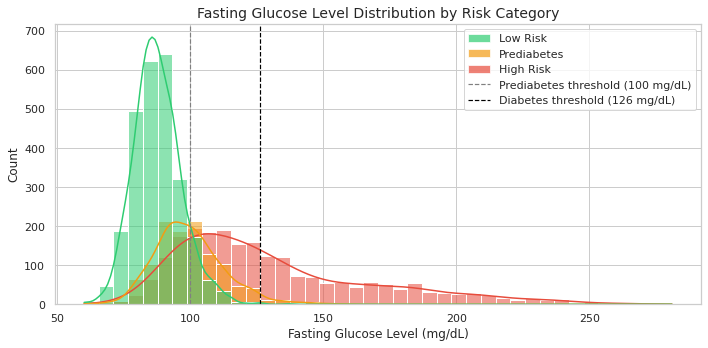

In [33]:
plt.figure(figsize=(10, 5))
ax = sns.histplot(
    data=df, x='fasting_glucose_level', hue='diabetes_risk_category',
    hue_order=RISK_ORDER, palette=RISK_COLORS, bins=40, kde=True, alpha=0.55
)

# Add threshold lines
ax.axvline(100, color='gray', linestyle='--', linewidth=1.2)
ax.axvline(126, color='black', linestyle='--', linewidth=1.2)

# Build combined legend: risk categories + threshold lines
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

risk_handles = [Patch(facecolor=c, alpha=0.7, label=l) for l, c in zip(RISK_ORDER, RISK_COLORS)]
line_handles = [
    Line2D([0], [0], color='gray',  linestyle='--', linewidth=1.2, label='Prediabetes threshold (100 mg/dL)'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=1.2, label='Diabetes threshold (126 mg/dL)'),
]
ax.legend(handles=risk_handles + line_handles, loc='upper right')

plt.title('Fasting Glucose Level Distribution by Risk Category', fontsize=14)
plt.xlabel('Fasting Glucose Level (mg/dL)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Interpretation:** Fasting glucose shows the clearest separation of any feature. *Low Risk* patients cluster below 100 mg/dL (the ADA prediabetes threshold), *Prediabetes* patients concentrate in the 100–126 mg/dL range, and *High Risk* patients are above 126 mg/dL — precisely matching the clinical diagnostic thresholds. This strongly supports our hypothesis that glucose is the dominant predictor. The distributions overlap in the 90–140 mg/dL range, which is where our model will face the most classification uncertainty, and also where clinical diagnosis is most ambiguous in practice.

### Plot 3 — Boxplot: BMI by Risk Category

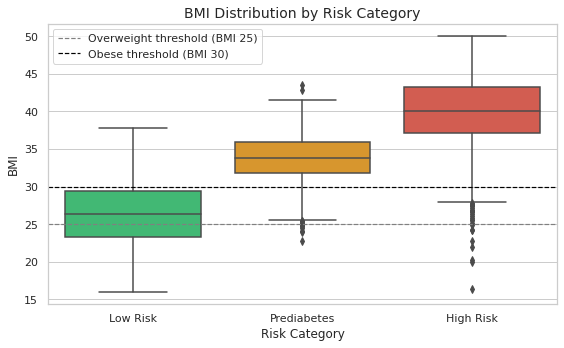

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df, x='diabetes_risk_category', y='bmi',
    order=RISK_ORDER, palette=RISK_COLORS
)
plt.axhline(25, color='gray', linestyle='--', linewidth=1.2, label='Overweight threshold (BMI 25)')
plt.axhline(30, color='black', linestyle='--', linewidth=1.2, label='Obese threshold (BMI 30)')
plt.legend()
plt.title('BMI Distribution by Risk Category', fontsize=14)
plt.xlabel('Risk Category')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

**Interpretation:** Median BMI rises progressively from *Low Risk* through *Prediabetes* to *High Risk*, confirming BMI as the second key predictor in our hypothesis. The *High Risk* median sits above the obesity threshold (BMI 30), consistent with the clinical mechanism — fat tissue causes insulin resistance, which directly drives Type 2 diabetes progression. However, the interquartile ranges overlap substantially across all three classes, meaning BMI alone cannot cleanly separate them; it must be combined with glucose and age to be useful as a predictor.

### Plot 4 — Correlation Heatmap (Numeric Features)

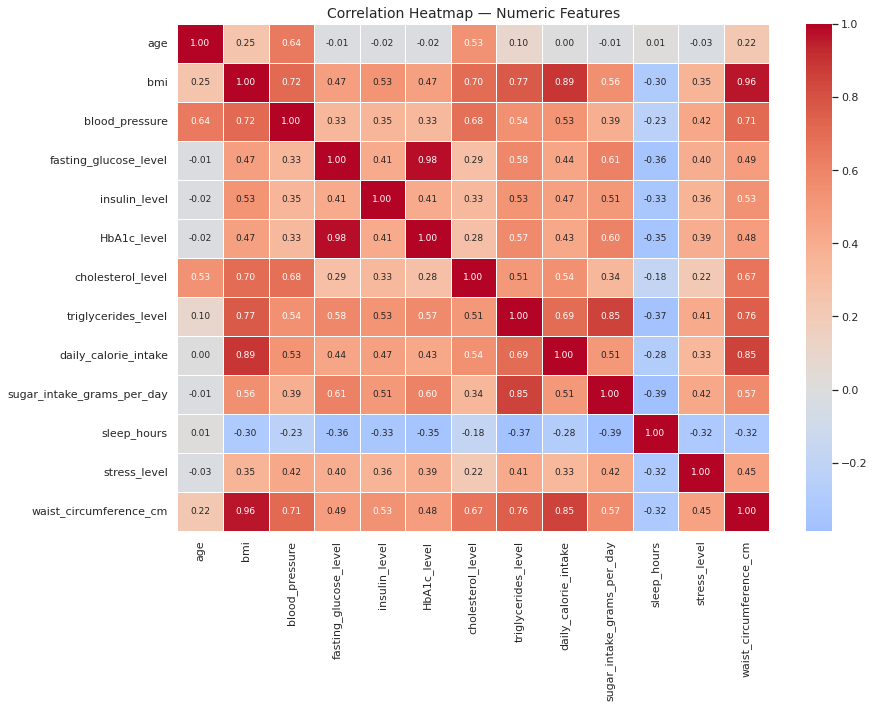

In [11]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, annot_kws={'size': 9}
)
plt.title('Correlation Heatmap — Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation:** Three findings stand out. First, `fasting_glucose_level` and `HbA1c_level` are strongly correlated (r ≈ 0.98) — both measure blood glucose over different time windows and carry overlapping information, so we will monitor for multicollinearity effects in Logistic Regression. Second, `bmi` and `waist_circumference_cm` are strongly correlated (r ≈ 0.96), which is expected since both measure adiposity. Third, `triglycerides_level` shows moderate correlation with several metabolic features, reflecting that dyslipidaemia and insulin resistance co-occur clinically. Features such as `sleep_hours` and `stress_level` show low inter-correlation with the rest, meaning they contribute independent information that may benefit non-linear models.

### Plot 5 — Boxplot: HbA1c Level by Risk Category

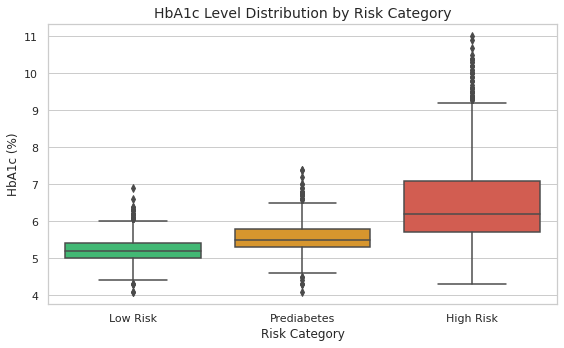

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df, x='diabetes_risk_category', y='HbA1c_level',
    order=RISK_ORDER, palette=RISK_COLORS
)
plt.title('HbA1c Level Distribution by Risk Category', fontsize=14)
plt.xlabel('Risk Category')
plt.ylabel('HbA1c (%)')
plt.tight_layout()
plt.show()

**Interpretation:** HbA1c — the gold-standard clinical marker for long-term blood glucose control — shows the cleanest class separation of all features, with almost no overlap in medians across the three groups. The *High Risk* median sits above 6.5%, which is the ADA diagnostic threshold for Type 2 diabetes; *Low Risk* patients are predominantly below 5.5%; and *Prediabetes* patients cluster in the 5.7–5.9% range — precisely matching the clinically defined prediabetes interval. This feature will likely be among the most important variables in all three of our Week 3 models.

### Plot 6 — KDE: Age Distribution by Risk Category

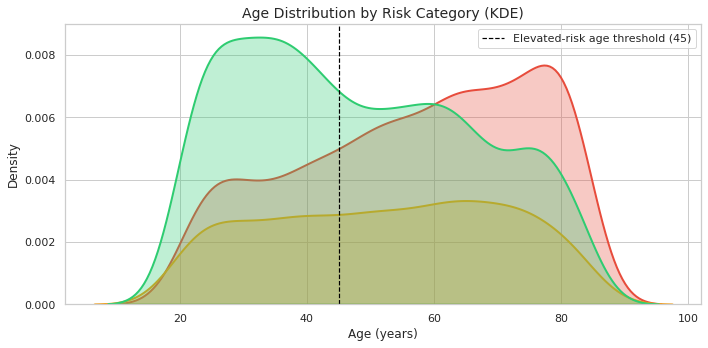

In [13]:
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df, x='age', hue='diabetes_risk_category',
    hue_order=RISK_ORDER, palette=RISK_COLORS,
    fill=True, alpha=0.3, linewidth=2
)
plt.axvline(45, color='black', linestyle='--', linewidth=1.2, label='Elevated-risk age threshold (45)')
plt.legend()
plt.title('Age Distribution by Risk Category (KDE)', fontsize=14)
plt.xlabel('Age (years)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

**Interpretation:** Age distributions overlap considerably across the three risk categories, making age the weakest individual separator of our three hypothesis features. A visible shift is still present: *High Risk* patients have a flatter distribution with higher density above age 45, while *Low Risk* patients are somewhat more concentrated at younger ages — consistent with our hypothesis that insulin sensitivity declines with age. The substantial overlap confirms that age alone is not sufficient for classification, and it will contribute most as a supporting feature in combination with glucose and BMI, particularly in tree-based models that can learn compound thresholds.

### Plot 7 — Stacked Bar: Physical Activity Level vs Risk Category

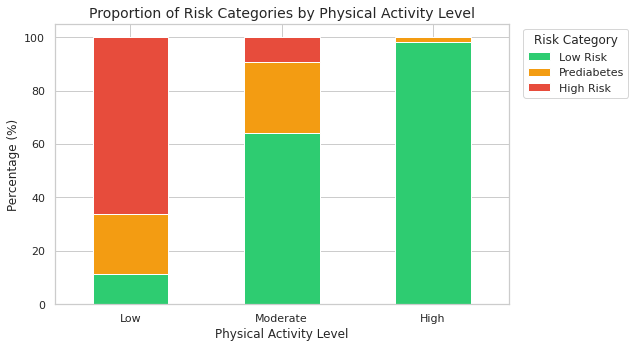

In [14]:
ct = pd.crosstab(df['physical_activity_level'], df['diabetes_risk_category'], normalize='index') * 100
ct = ct[RISK_ORDER]
ct.loc[['Low', 'Moderate', 'High']].plot(
    kind='bar', stacked=True, figsize=(9, 5),
    color=RISK_COLORS, edgecolor='white'
)
plt.title('Proportion of Risk Categories by Physical Activity Level', fontsize=14)
plt.xlabel('Physical Activity Level')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Risk Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretation:** Patients with *Low* physical activity have a noticeably higher proportion of *High Risk* classification compared to those with *Moderate* or *High* activity levels, where *Low Risk* becomes more dominant. This confirms that physical activity is an informative lifestyle feature — inactivity is a recognised risk factor for diabetes because regular exercise improves insulin sensitivity. Although less discriminative than glucose or HbA1c individually, this feature provides independent lifestyle signal that complements the clinical measurements, and will be particularly valuable for tree-based models that can discover multi-feature interaction thresholds.

---
## 3. Missing Value Handling

In [15]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values detected in any column.')

Missing values per column:
No missing values detected in any column.


**Missing Value Decision:**  
The dataset contains **zero missing values** across all 17 remaining columns. This is confirmed both by `df.isnull().sum()` above and by the original `df.describe()` showing `count = 6000` for every numeric column. No imputation strategy is required for any column, and we proceed to feature engineering without dropping any rows. This means the full 6,000 records will flow into the train/test split.

---
## 4. Feature Engineering

### 4.1 New Feature: `glucose_bmi_interaction`

We create one new composite feature by multiplying `fasting_glucose_level` by `bmi`. Clinical literature shows that the combination of hyperglycaemia and obesity is synergistically harmful — adipose tissue causes insulin resistance, which amplifies the metabolic effect of elevated glucose. A patient with both high glucose *and* high BMI faces a disproportionately elevated risk compared to one with only one elevated value. This multiplicative interaction term captures that non-additive relationship, which is difficult for Logistic Regression (our required baseline, a linear model) to learn from the raw features alone. By explicitly including the product term, we give the linear model access to the interaction without needing a kernel.

In [16]:
df['glucose_bmi_interaction'] = df['fasting_glucose_level'] * df['bmi']
print('New feature created: glucose_bmi_interaction')
print(df['glucose_bmi_interaction'].describe())

New feature created: glucose_bmi_interaction
count     6000.000000
mean      3606.164017
std       1679.959722
min       1088.000000
25%       2358.400000
50%       3223.850000
75%       4315.925000
max      12000.000000
Name: glucose_bmi_interaction, dtype: float64


### 4.2 Encoding Categorical Features

We have three categorical input features that must be encoded before modelling:

| Feature | Unique values | Encoding choice | Reasoning |
|---|---|---|---|
| `gender` | Male, Female (2) | Binary label encoding (0/1) | Only 2 categories; one-hot would be redundant (introduces perfect multicollinearity) |
| `physical_activity_level` | Low, Moderate, High (3) | Ordinal encoding (0, 1, 2) | The three levels have a natural order — Low < Moderate < High. Ordinal encoding preserves this ordering, which is especially beneficial for tree-based and linear models |
| `family_history_diabetes` | No, Yes (2) | Binary label encoding (0/1) | Binary categorical; no ordering ambiguity |

The target variable `diabetes_risk_category` is encoded with ordinal label encoding: Low Risk=0, Prediabetes=1, High Risk=2.

In [17]:
# Gender: Female=0, Male=1
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

# Physical activity: ordinal Low < Moderate < High
activity_order = {'Low': 0, 'Moderate': 1, 'High': 2}
df['physical_activity_level'] = df['physical_activity_level'].map(activity_order)

# Family history: No=0, Yes=1
df['family_history_diabetes'] = df['family_history_diabetes'].map({'No': 0, 'Yes': 1})

# Target variable: ordinal encoding preserving risk severity order
target_order = {'Low Risk': 0, 'Prediabetes': 1, 'High Risk': 2}
df['diabetes_risk_category'] = df['diabetes_risk_category'].map(target_order)

print('Encoding complete. Updated dtypes:')
print(df[['gender', 'physical_activity_level', 'family_history_diabetes', 'diabetes_risk_category']].dtypes)
print()
print('Sample after encoding:')
print(df[['gender', 'physical_activity_level', 'family_history_diabetes', 'diabetes_risk_category']].head())

Encoding complete. Updated dtypes:
gender                     int64
physical_activity_level    int64
family_history_diabetes    int64
diabetes_risk_category     int64
dtype: object

Sample after encoding:
   gender  physical_activity_level  family_history_diabetes  \
0       0                        0                        0   
1       1                        2                        0   
2       1                        0                        1   
3       0                        0                        1   
4       1                        1                        1   

   diabetes_risk_category  
0                       1  
1                       0  
2                       2  
3                       2  
4                       1  


---
## 5. Scaling & Preprocessing

**Scaler choice: `StandardScaler` (zero mean, unit variance)**  

We use `StandardScaler` rather than `MinMaxScaler` for two reasons. First, our dataset contains clinically extreme values (e.g., glucose above 200 mg/dL, BMI above 45) that represent genuine high-risk patients and must be retained. `MinMaxScaler` anchors its 0–1 range to the minimum and maximum of each feature, so a single extreme value compresses the rest of the distribution into a narrow interval. `StandardScaler` is more robust because it uses the mean and standard deviation rather than range boundaries. Second, two of our planned Week 3 models — Logistic Regression (required baseline) and KNN — are sensitive to feature scale: without scaling, a feature like `daily_calorie_intake` (range ~1,000–3,500) would dominate over `sleep_hours` (range 4–10) purely due to magnitude.

**Critical: the scaler will be fitted on `X_train` only in Section 6 — never on the full dataset.** Fitting on the full dataset before splitting would expose the training process to test-set statistics, which is data leakage.

In [18]:
# Separate features and target
X = df.drop(columns=['diabetes_risk_category'])
y = df['diabetes_risk_category']

print('Features shape:', X.shape)
print('Target shape:  ', y.shape)
print('Feature columns:', list(X.columns))

Features shape: (6000, 17)
Target shape:   (6000,)
Feature columns: ['age', 'gender', 'bmi', 'blood_pressure', 'fasting_glucose_level', 'insulin_level', 'HbA1c_level', 'cholesterol_level', 'triglycerides_level', 'physical_activity_level', 'daily_calorie_intake', 'sugar_intake_grams_per_day', 'sleep_hours', 'stress_level', 'family_history_diabetes', 'waist_circumference_cm', 'glucose_bmi_interaction']


---
## 6. Train / Test Split

**Correct order of operations — no data leakage:**
1. Split the data into train and test sets first
2. Fit the scaler **on `X_train` only** (`scaler.fit(X_train)`)
3. Transform both sets using that fitted scaler (`scaler.transform(X_test)`)

We use `stratify=y` to ensure the 80/20 class proportions are preserved in both subsets — this is especially important given the class imbalance (Prediabetes at 19.2%).

In [19]:
# Step 1: Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Fit scaler on TRAINING SET ONLY
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on train
X_test_scaled  = scaler.transform(X_test)        # transform only on test

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

# Confirm shapes
print('X_train shape:', X_train_scaled.shape)
print('X_test  shape:', X_test_scaled.shape)
print('y_train shape:', y_train.shape)
print('y_test  shape:', y_test.shape)
print()
print('Train class distribution (0=Low Risk, 1=Prediabetes, 2=High Risk):')
print(y_train.value_counts().sort_index())
print()
print('Test class distribution (0=Low Risk, 1=Prediabetes, 2=High Risk):')
print(y_test.value_counts().sort_index())

X_train shape: (4800, 17)
X_test  shape: (1200, 17)
y_train shape: (4800,)
y_test  shape: (1200,)

Train class distribution (0=Low Risk, 1=Prediabetes, 2=High Risk):
0    2082
1     922
2    1796
Name: diabetes_risk_category, dtype: int64

Test class distribution (0=Low Risk, 1=Prediabetes, 2=High Risk):
0    520
1    231
2    449
Name: diabetes_risk_category, dtype: int64
